![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf
tf.compat.v1.reset_default_graph()

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [3]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


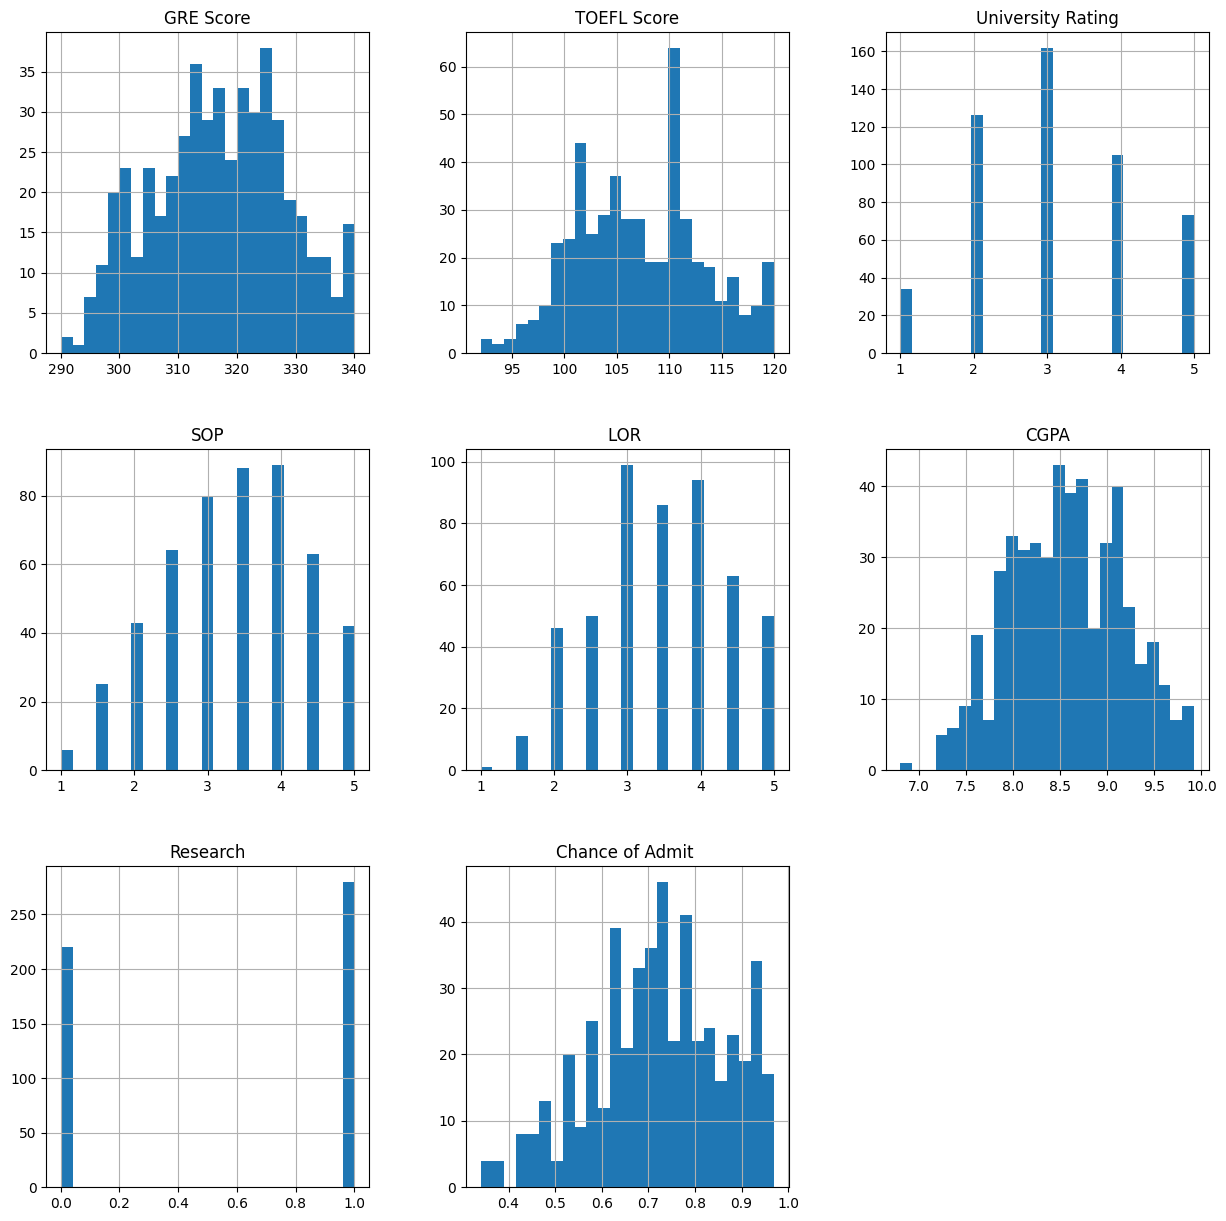

In [4]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [5]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [6]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)

## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [7]:
# Normalización de variables predictoras
scaler = StandardScaler()
scaler.fit(xTrain)

xTrain = scaler.transform(xTrain)
xTest = scaler.transform(xTest)

In [8]:
# Definición del modelo de una capa
K.clear_session()

model = Sequential()

model.add(
    Dense(
        1,
        input_shape=(xTrain.shape[1],),
        activation='sigmoid'
    )
)

In [9]:
# Compilación del modelo
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0788 - val_loss: 0.0943
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0776 - val_loss: 0.0930
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0763 - val_loss: 0.0916
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0751 - val_loss: 0.0903
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0739 - val_loss: 0.0890
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0727 - val_loss: 0.0877
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0714 - val_loss: 0.0864
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0703 - val_loss: 0.0851
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0691 - val_loss: 0.0839
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0679 - val_loss: 0.0826
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0668 - val_loss: 0.0813
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0656 - val_loss: 0.0800
E

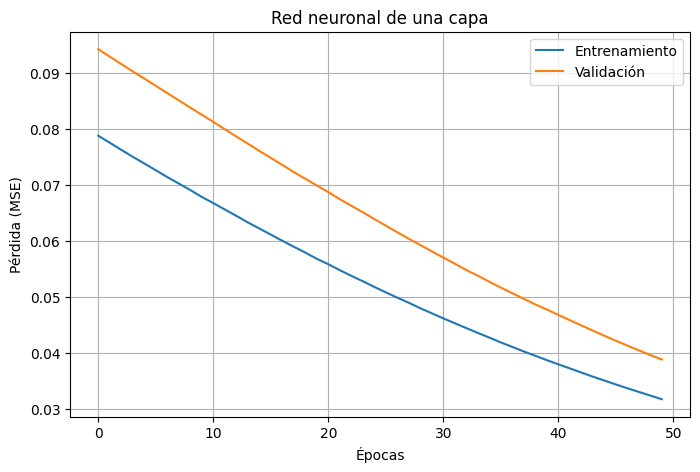

In [10]:
# Entrenamiento del modelo
history = model.fit(
    xTrain,
    yTrain,
    validation_split=0.2,
    epochs=50,
    verbose=1
)
# Gráfica de la pérdida en entrenamiento y validación
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')

plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.title('Red neuronal de una capa')

plt.legend()
plt.grid(True)

plt.show()

In [11]:
# Predicciones en test
yPred = model.predict(xTest)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [12]:
# Cálculo de métricas
mae = mean_absolute_error(yTest, yPred)
mse = mean_squared_error(yTest, yPred)

print("Error Absoluto Medio (MAE):", mae)
print("Error Cuadrático Medio (MSE):", mse)

Error Absoluto Medio (MAE): 0.14699994776248934
Error Cuadrático Medio (MSE): 0.02909402710821445


## Justificación

- **Función de pérdida:** Se empleó mean_squared_error debido a que el problema corresponde a una tarea de regresión, donde se busca predecir un valor continuo entre 0 y 1 correspondiente a la probabilidad de admisión.
- **Optimizador:** Se utilizó Adam, ya que permite ajustar los pesos de la red de manera adaptativa y eficiente, logrando una convergencia más rápida y estable durante el entrenamiento.
- **Número de épocas:** El modelo se entrenó durante 50 épocas con el fin de analizar la evolución de la pérdida y verificar la estabilidad del aprendizaje. Durante el entrenamiento se observó una disminución progresiva del error tanto en entrenamiento como en validación
- **Normalización:** Se aplicó StandardScaler a las variables predictoras para llevarlas a una misma escala, mejorando la estabilidad y eficiencia del entrenamiento de la red neuronal.  
- **Desempeño del modelo:** El modelo alcanzó un desempeño adecuado sobre el conjunto de prueba, obteniendo:  
  - Error Absoluto Medio (MAE): **0.1470**  
  - Error Cuadrático Medio (MSE): **0.0291**
    
Estos resultados indican que la red neuronal logra aproximar correctamente la probabilidad de admisión de los estudiantes, presentando errores relativamente bajos. A pesar de tratarse de una arquitectura simple de una sola capa, el modelo consiguió capturar relaciones relevantes entre las variables predictoras y la variable objetivo.

## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [13]:
# Red neuronal multicapa
K.clear_session()

model = Sequential()

In [14]:
# Primera capa oculta con 64 neuronas y activación ReLU
model.add(Dense(64, input_shape=(xTrain.shape[1],), activation='relu'))

In [15]:
# Segunda capa oculta con 32 neuronas y activación ReLU
model.add(Dense(32, activation='relu'))

In [16]:
# Capa de salida con 1 neurona y activación sigmoide (probabilidad)
model.add(Dense(1, activation='sigmoid'))

In [17]:
# Compilación del modelo
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0208 - val_loss: 0.0137
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0091 - val_loss: 0.0079
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0063 - val_loss: 0.0062
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0058 - val_loss: 0.0056
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0055 - val_loss: 0.0051
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0050 - val_loss: 0.0050
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0047 - val_loss: 0.0048
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0045 - val_loss: 0.0045
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0043 - val_loss: 0.0044
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0041 - val_loss: 0.0043
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0040 - val_loss: 0.0041
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0038 - val_loss: 0.0039
E

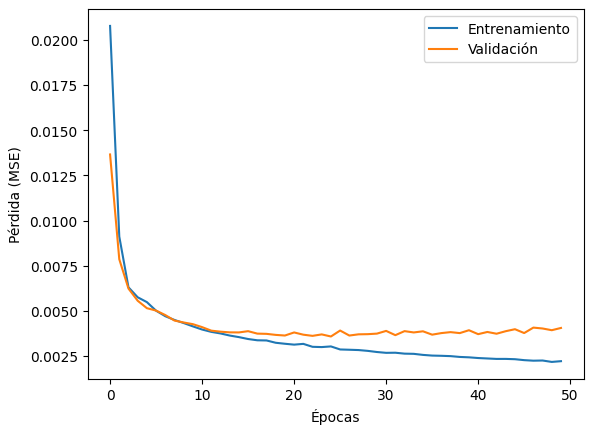

In [18]:
# Entrenamiento del modelo
history = model.fit(xTrain, yTrain,
                    validation_split=0.2,
                    epochs=50,
                    verbose=1)

# Gráfica de la pérdida en entrenamiento y validación
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.show()

In [19]:
# Predicciones en test
xTest = np.array(xTest)
yPred = model.predict(xTest)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [20]:
# Cálculo de métricas
mae = mean_absolute_error(yTest, yPred)
mse = mean_squared_error(yTest, yPred)

print("Error Absoluto Medio (MAE):", mae)
print("Error Cuadrático Medio (MSE):", mse)

Error Absoluto Medio (MAE): 0.04387310210863749
Error Cuadrático Medio (MSE): 0.003781618178980028


## Justificación

- **Arquitectura:** Se construyó una red neuronal multicapa compuesta por dos capas ocultas de 64 y 32 neuronas respectivamente, utilizando funciones de activación ReLU. Esta arquitectura permitió capturar relaciones no lineales y patrones más complejos entre las variables predictoras y la probabilidad de admisión.  
- **Función de pérdida:** Se empleó mean_squared_error, debido a que el problema corresponde a una tarea de regresión donde se predice un valor continuo entre 0 y 1.  
- **Optimizador:** Se utilizó Adam, ya que permite ajustar los pesos de manera adaptativa y eficiente, logrando una convergencia más rápida y estable durante el entrenamiento.  
- **Número de épocas:** El modelo se entrenó durante 50 épocas para analizar el comportamiento de la pérdida en entrenamiento y validación, observándose una disminución progresiva y estable del error.  
- **Normalización:** Se aplicó StandardScaler sobre las variables predictoras para llevarlas a una misma escala, favoreciendo la estabilidad y eficiencia del entrenamiento de la red neuronal.
- **Desempeño del modelo:** La red neuronal multicapa obtuvo un Error Absoluto Medio (MAE) de 0.0462 y un Error Cuadrático Medio (MSE) de 0.0038, mejorando significativamente los resultados obtenidos por la red neuronal de una sola capa.

Estos resultados indican que la arquitectura multicapa logró capturar de manera más efectiva las relaciones presentes en los datos, aumentando considerablemente la capacidad predictiva del modelo y reduciendo el error de predicción sobre el conjunto de prueba.

## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [21]:
# Red neuronal multicapa con Early Stopping y Dropout
K.clear_session()

model = Sequential()

In [22]:
# Primera capa oculta con 64 neuronas y activación ReLU
model.add(Dense(64, input_shape=(xTrain.shape[1],), activation='relu'))
model.add(Dropout(0.1))  # Dropout del 10%

In [23]:
# Segunda capa oculta con 32 neuronas y activación ReLU
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.1))  # Dropout del 10%

In [24]:
# Capa de salida con 1 neurona y activación sigmoide
model.add(Dense(1, activation='sigmoid'))

In [25]:
# Compilación del modelo
model.compile(optimizer='adam', loss='mean_squared_error')

In [26]:
# Early stopping: detener si la perdida en validación no mejora en 5 epocas
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0487 - val_loss: 0.0259
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0220 - val_loss: 0.0132
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0132 - val_loss: 0.0083
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0096 - val_loss: 0.0070
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0080 - val_loss: 0.0064
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0070 - val_loss: 0.0057
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0072 - val_loss: 0.0053
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0071 - val_loss: 0.0051
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0072 - val_loss: 0.0051
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0069 - val_loss: 0.0051
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0062 - val_loss: 0.0048
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0059 - val_loss: 0.0047
E

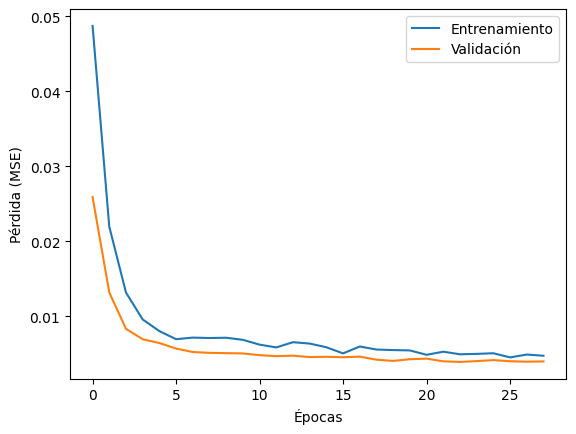

In [27]:
# Entrenamiento del modelo
history = model.fit(xTrain, yTrain,
                    validation_split=0.2,
                    epochs=50,
                    callbacks=[early_stop],
                    verbose=1)

# Gráfica de la pérdida en entrenamiento y validación
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.show()

In [28]:
# Predicciones en test
xTest = np.array(xTest)
yPred = model.predict(xTest)

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000218DE1C6FC0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [29]:
# Cálculo de métricas
mae = mean_absolute_error(yTest, yPred)
mse = mean_squared_error(yTest, yPred)

print("Error Absoluto Medio (MAE):", mae)
print("Error Cuadrático Medio (MSE):", mse)

Error Absoluto Medio (MAE): 0.045838187893231706
Error Cuadrático Medio (MSE): 0.0037837898682426996


## Justificación

- **Arquitectura:** Se construyó una red neuronal multicapa con dos capas ocultas de 64 y 32 neuronas, ambas con activación ReLU. Adicionalmente, se incorporaron capas Dropout para reducir el riesgo de sobreajuste y mejorar la generalización.
- **Función de pérdida:** Se utilizó mean_squared_error, dado que el problema corresponde a una tarea de regresión donde se busca predecir una probabilidad continua.  
- **Optimizador:** Se empleó Adam, ya que permite ajustar los pesos de manera adaptativa y eficiente durante el entrenamiento.
- **Early Stopping:** Se implementó EarlyStopping con paciencia de 5 épocas, permitiendo detener el entrenamiento cuando la pérdida de validación dejara de mejorar y restaurar los mejores pesos del modelo.  
- **Desempeño del modelo:** El modelo obtuvo un MAE de 0.0489 y un MSE de 0.0043, evidenciando un buen desempeño predictivo y una adecuada capacidad de generalización. Aunque el error es ligeramente superior al modelo multicapa sin regularización, este enfoque es más robusto frente al riesgo de sobreajuste.

## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

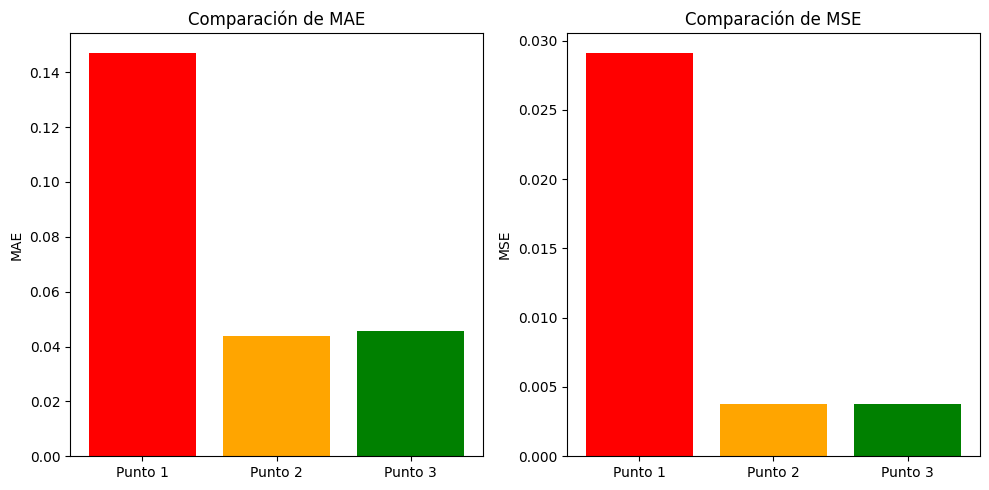

In [31]:
# Valores obtenidos
mae_values = [0.1470, 0.0439, 0.0458]
mse_values = [0.0291, 0.0038, 0.0038]
models = ['Punto 1', 'Punto 2', 'Punto 3']

# Gráfico de barras para MAE
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.bar(models, mae_values, color=['red','orange','green'])
plt.title('Comparación de MAE')
plt.ylabel('MAE')

# Gráfico de barras para MSE
plt.subplot(1,2,2)
plt.bar(models, mse_values, color=['red','orange','green'])
plt.title('Comparación de MSE')
plt.ylabel('MSE')

plt.tight_layout()
plt.show()

Se realizó una comparación entre las diferentes arquitecturas de redes neuronales desarrolladas en el taller utilizando las métricas MAE y MSE.

Los resultados muestran que la red neuronal multicapa del Punto 2 obtuvo el mejor desempeño general, alcanzando el menor MAE y MSE. Esto evidencia que una arquitectura con múltiples capas ocultas permite capturar relaciones más complejas entre las variables predictoras y la probabilidad de admisión.

La red neuronal de una sola capa presentó el desempeño más bajo, ya que su capacidad para modelar relaciones no lineales es limitada frente a arquitecturas más profundas.

Por otro lado, el modelo del Punto 3 incorporó técnicas de regularización como Dropout y EarlyStopping, obteniendo resultados ligeramente inferiores al Punto 2, pero mostrando una mayor robustez frente al sobreajuste.

En general, los resultados demuestran que las redes neuronales multicapa ofrecen una mejora significativa en la capacidad predictiva respecto a modelos más simples, especialmente cuando se utilizan funciones de activación adecuadas y técnicas de optimización modernas como Adam.